# ISLES'22 - FLAIR hizalama dogrulamasi (Parca 2b kalani)

Parca 2b FLAIR onbellegini uretti (250/250 `_f.npy` Drive'da) ama son iki cikti eksik kaldi:
gorsel hucresi `np.ptp` hatasiyla durdu, sonraki hucre hic calismadi.

| Eksik cikti | Ne icin |
|---|---|
| `ozet/flair_hizalama.png` | Header tabanli hizalamanin gorsel dogrulamasi - beyin sinirlari ortusuyor mu |
| `ozet/flair_hizalama.xlsx` | Vaka basina hizalama maliyeti - Bolum 3 gecikme butcesine giren sayi |

**Bagimsiz notebook**, bastan sona calistirilir. Gorsel saniyeler surer; hizalama olcumu
250 vakada ~5 dk (yalniz `resample_from_to` cagrisi olculuyor, tam on isleme degil).

In [1]:
import os, json, glob, re, time
from pathlib import Path

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'


def drive_bagla(nokta='/content/drive'):
    if ORTAM != 'colab':
        return None
    from google.colab import drive
    if os.path.ismount(nokta):
        print('Drive zaten bagli:', nokta)
        return nokta
    try:
        drive.mount(nokta)
    except ValueError as e:
        print('duz mount basarisiz (%s) -> force_remount' % e)
        drive.mount(nokta, force_remount=True)
    return nokta


drive_bagla()

PROJE = '/content/drive/MyDrive/iskemik_inme' if ORTAM == 'colab' else str(Path.cwd())
DATA_ROOT = os.path.join(PROJE, 'ISLES-2022')
HAZIR = os.path.join(PROJE, 'hazir')
OZET_DIR = os.path.join(PROJE, 'ozet')
os.makedirs(OZET_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nibabel.processing import resample_from_to

CFG = json.load(open(os.path.join(HAZIR, 'config.json')))
EVAL_CASES = json.load(open(os.path.join(PROJE, 'eval_cases.json')))
print('PROJE:', PROJE)
print('FLAIR onbellegi:', len([q for q in os.listdir(HAZIR) if q.endswith('_f.npy')]), 'dosya')

Drive zaten bagli: /content/drive
PROJE: /content/drive/MyDrive/iskemik_inme
FLAIR onbellegi: 250 dosya


## 1. Gorsel dogrulama

Onbellekteki `_f.npy` dosyalarindan ciziliyor - yeniden hizalama yapilmiyor.
Son panelde DWI kirmizi, FLAIR yesil: **beyin sinirlari ust uste dusmeli.** Dusmuyorsa
header tabanli tasima yetersiz demektir ve A1 ablasyonunun negatif sonucu bununla
aciklanir (bkz. `PLAN.md` Bolum 5l).

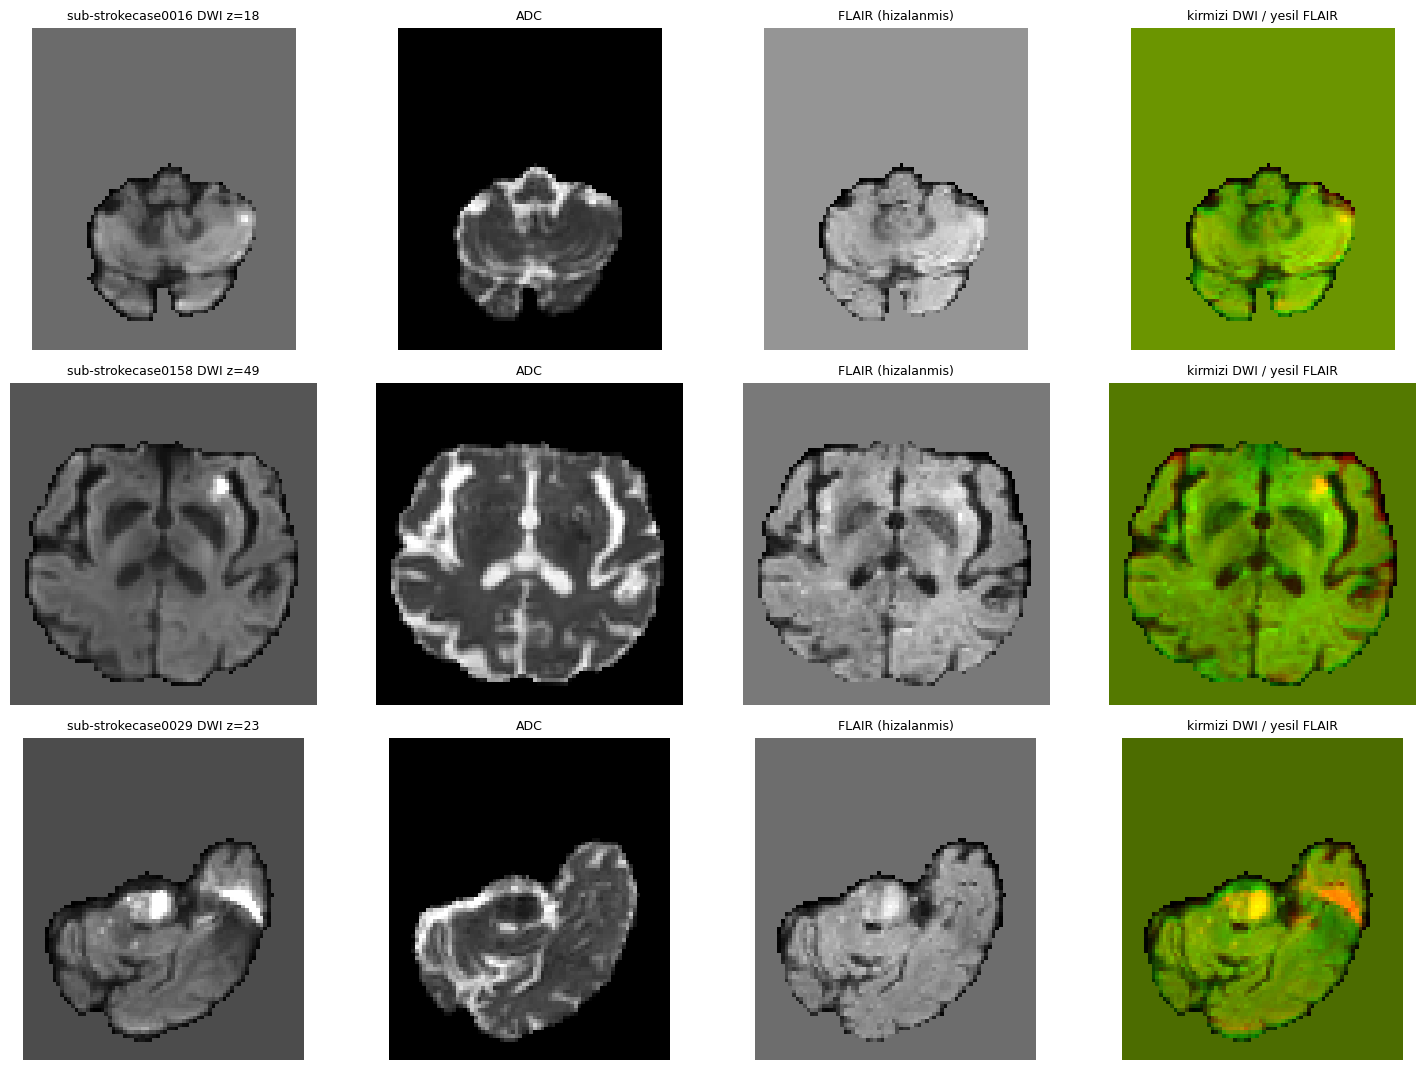

yazildi: ozet/flair_hizalama.png


In [2]:
ornek = EVAL_CASES[:3]
fig, ax = plt.subplots(len(ornek), 4, figsize=(15, 3.6 * len(ornek)))
for i, v in enumerate(ornek):
    x = np.load(os.path.join(HAZIR, f'{v}_x.npy')).astype(np.float32)
    f = np.load(os.path.join(HAZIR, f'{v}_f.npy')).astype(np.float32)
    y = np.load(os.path.join(HAZIR, f'{v}_y.npy'))
    z = int(np.argmax(y.sum(axis=(0, 1)))) if y.any() else y.shape[2] // 2

    ax[i, 0].imshow(x[0, :, :, z].T, cmap='gray', origin='lower')
    ax[i, 0].set_title(f'{v} DWI z={z}', fontsize=9)
    ax[i, 1].imshow(x[1, :, :, z].T, cmap='gray', origin='lower')
    ax[i, 1].set_title('ADC', fontsize=9)
    ax[i, 2].imshow(f[0, :, :, z].T, cmap='gray', origin='lower')
    ax[i, 2].set_title('FLAIR (hizalanmis)', fontsize=9)

    rgb = np.zeros((*x[0, :, :, z].T.shape, 3))
    nrm = lambda a: (a - a.min()) / (np.ptp(a) + 1e-6)   # ndarray.ptp NumPy 2.0'da kaldirildi
    rgb[..., 0] = nrm(x[0, :, :, z].T)
    rgb[..., 1] = nrm(f[0, :, :, z].T)
    ax[i, 3].imshow(rgb, origin='lower')
    ax[i, 3].set_title('kirmizi DWI / yesil FLAIR', fontsize=9)
    for j in range(4):
        ax[i, j].set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(OZET_DIR, 'flair_hizalama.png'), dpi=130, bbox_inches='tight')
plt.show()
print('yazildi: ozet/flair_hizalama.png')

## 2. Hizalama maliyeti - 250 vaka

Olculen sey yalniz **`resample_from_to` cagrisi**: FLAIR'i DWI grid'ine tasiyan adim.
Parca 2b'deki tam `flair_hazirla` bundan fazlasini yapiyordu (iki resample + beyin maskesi);
gecikme butcesine giren sayi ise yalniz bu hizalama adimi.

In [3]:
VAKA_RE = re.compile(r'(sub-[A-Za-z0-9]+)')
tum = [q for q in glob.glob(os.path.join(DATA_ROOT, '**', '*.nii.gz'), recursive=True)]
yollar = {}
for q in tum:
    v = next(iter(VAKA_RE.findall(q)), None)
    ad = os.path.basename(q).lower().replace('.nii.gz', '')
    if v is None:
        continue
    if ad.endswith('_dwi'):
        yollar.setdefault(v, {})['dwi'] = q
    elif ad.endswith('flair'):
        yollar.setdefault(v, {})['flair'] = q

vakalar = sorted(v for v, d in yollar.items() if 'dwi' in d and 'flair' in d)
print('vaka:', len(vakalar))

kayit = []
t0 = time.time()
for i, v in enumerate(vakalar):
    dwi_im, fl_im = nib.load(yollar[v]['dwi']), nib.load(yollar[v]['flair'])
    _ = np.asarray(fl_im.dataobj)          # okuma olcum disinda
    t = time.perf_counter()
    resample_from_to(fl_im, dwi_im, order=1)
    kayit.append(dict(vaka=v, hizalama_sn=time.perf_counter() - t,
                      flair_sekil='x'.join(map(str, fl_im.shape[:3])),
                      flair_voxel=float(np.prod(fl_im.header.get_zooms()[:3]))))
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(vakalar)}  ({time.time()-t0:.0f} sn)')

hz = pd.DataFrame(kayit)
print()
print(hz.hizalama_sn.describe().to_string())
print()
print(f'MEDYAN {hz.hizalama_sn.median()*1000:.0f} ms/vaka')

vaka: 250
  50/250  (55 sn)
  100/250  (125 sn)
  150/250  (188 sn)
  200/250  (221 sn)
  250/250  (251 sn)

count    250.000000
mean       0.569533
std        0.533290
min        0.044273
25%        0.219635
50%        0.669694
75%        0.740508
max        4.734815

MEDYAN 670 ms/vaka


In [4]:
hz.to_excel(os.path.join(OZET_DIR, 'flair_hizalama.xlsx'), index=False)

medyan_ms = hz.hizalama_sn.median() * 1000
ozet = dict(
    vaka=len(hz),
    hizalama_medyan_ms=round(float(medyan_ms), 1),
    hizalama_ort_ms=round(float(hz.hizalama_sn.mean() * 1000), 1),
    hizalama_std_ms=round(float(hz.hizalama_sn.std() * 1000), 1),
    hizalama_min_ms=round(float(hz.hizalama_sn.min() * 1000), 1),
    hizalama_max_ms=round(float(hz.hizalama_sn.max() * 1000), 1),
    onbellek_gb=round(sum(os.path.getsize(os.path.join(HAZIR, q))
                          for q in os.listdir(HAZIR) if q.endswith('.npy')) / 1e9, 2),
    flair_dosya=len([q for q in os.listdir(HAZIR) if q.endswith('_f.npy')]),
)
json.dump(ozet, open(os.path.join(OZET_DIR, 'flair_ozeti.json'), 'w'), indent=2)
for k, v in ozet.items():
    print(f'{k:22s} {v}')

print()
print('Karsilastirma (PLAN Bolum 6): unet3d TensorRT fp16 uctan uca ~75 ms/vaka.')
print(f'FLAIR hizalamasi tek basina {medyan_ms/75:.0f} kati.')
print()
print('yazildi: ozet/flair_hizalama.xlsx, ozet/flair_ozeti.json, ozet/flair_hizalama.png')

vaka                   250
hizalama_medyan_ms     669.7
hizalama_ort_ms        569.5
hizalama_std_ms        533.3
hizalama_min_ms        44.3
hizalama_max_ms        4734.8
onbellek_gb            1.07
flair_dosya            250

Karsilastirma (PLAN Bolum 6): unet3d TensorRT fp16 uctan uca ~75 ms/vaka.
FLAIR hizalamasi tek basina 9 kati.

yazildi: ozet/flair_hizalama.xlsx, ozet/flair_ozeti.json, ozet/flair_hizalama.png
